# 05 — Soft vs good reactor days (chemistry / field)

**Why this notebook exists**

Notebook 04 / 04b used LASSO/Ridge to predict **continuous** removal %. Most days sit near a high ceiling, so that question is hard and chronological R² was weak / failed.

Here we ask a clearer question: **what looks different on softer reactor days vs good days?**

| | |
|--|--|
| **Soft day** | `removal_3320_3340` **< 95%** (default; later we sweep nearby cutoffs) |
| **Good day** | `removal_3320_3340` ≥ threshold |
| **Why 3320→3340** | Blend → effluent is reactor-relevant; 3310→3340 can stay ~99% even when reactors soften |
| **Compare** | Chemistry / field at 3310 & 3320 (+ blend topology features) |
| **Excluded from driver compare** | Other `*_3340` columns (downstream of reactors); we still report `dioxane_3340` as context |
| **Classifier** | Soft-day logistic model (time split); excludes `dioxane_3320`, `blend_ratio`, `sed_blend_gap` |
| **Phase 1 add-ons** | SHAP feature importance + soft-threshold sensitivity (90–98%) |
| **Outputs** | `data/processed/analysis_results/nb05_*` |

**Honest limit:** group differences are **associations**, not causation.


## Step 1 — Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_theme(style="whitegrid")


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "processed").is_dir():
            return candidate
    raise FileNotFoundError("Could not find project root.")


PROJECT_ROOT = find_project_root()
PROC = PROJECT_ROOT / "data/processed"
CHEM_PATH = PROC / "bts_chemistry_field_by_date.csv"
OUT_DIR = PROC / "analysis_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

Y_COL = "removal_3320_3340"
SOFT_THRESHOLD = 95.0
SOFT_THRESHOLDS = [90.0, 92.0, 95.0, 97.0, 98.0]
TRAIN_END = "2016-12-31"
MIN_COVERAGE = 0.40

if not CHEM_PATH.exists():
    raise FileNotFoundError(f"Run Notebook 01 first. Missing: {CHEM_PATH}")

print("Project root:", PROJECT_ROOT)
print("Chemistry:", CHEM_PATH)
print(f"Soft day: {Y_COL} < {SOFT_THRESHOLD}%")
print("Outputs:", OUT_DIR)

Project root: /Users/shaivikoul/Documents/DIOPredict LOWRY
Chemistry: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/bts_chemistry_field_by_date.csv
Soft day: removal_3320_3340 < 95.0%
Outputs: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results


## Step 2 — Load data, label soft vs good

In [2]:
df = pd.read_csv(CHEM_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

# Notebook 01 does not export removal_3320_3340 — compute if missing
if Y_COL not in df.columns:
    df[Y_COL] = (df["dioxane_3320"] - df["dioxane_3340"]) / df["dioxane_3320"] * 100

df = df.dropna(subset=[Y_COL]).copy()
df["y3320"] = df[Y_COL]
df["day_type"] = np.where(df["y3320"] < SOFT_THRESHOLD, "soft", "good")
df["is_soft"] = (df["day_type"] == "soft").astype(int)

# Process / topology features (no 3340 in the ratio)
df["blend_ratio"] = df["dioxane_3320"] / df["dioxane_3310"]
df["sed_blend_gap"] = df["dioxane_3310"] - df["dioxane_3320"]

df["era"] = np.select(
    [df["date"] < "2010-01-01", df["date"] < "2014-01-01", df["date"] < "2017-01-01"],
    ["2004-2009", "2010-2013", "2014-2016"],
    default="2017-2025",
)

print(f"Rows with {Y_COL}: {len(df)}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print("\nDay-type counts:")
print(df["day_type"].value_counts())
print("\nY3320 by day type:")
print(df.groupby("day_type")["y3320"].agg(["count", "min", "median", "max"]).round(3))

if "removal_3310_3340" in df.columns:
    soft = df[df["day_type"] == "soft"]
    print("\nOn SOFT reactor days:")
    print(f"  median Y3320 = {soft['y3320'].median():.2f}%")
    print(f"  median Y3310 = {soft['removal_3310_3340'].median():.2f}%")
    print(f"  median effluent dioxane = {soft['dioxane_3340'].median():.1f}")
    print(
        f"  fraction with Y3310 still ≥99% = {(soft['removal_3310_3340'] >= 99).mean():.1%}"
    )

era_tbl = (
    df.groupby("era", sort=False)
    .agg(
        n=("y3320", "size"),
        n_soft=("is_soft", "sum"),
        soft_rate=("is_soft", "mean"),
        med_y3320=("y3320", "median"),
        min_y3320=("y3320", "min"),
    )
    .reset_index()
)
print("\nSoft rate by era:")
print(era_tbl.round(3).to_string(index=False))
era_tbl.to_csv(OUT_DIR / "nb05_soft_rate_by_era.csv", index=False)

Rows with removal_3320_3340: 1105
Date range: 2004-04-21 → 2025-09-02

Day-type counts:
day_type
good    879
soft    226
Name: count, dtype: int64

Y3320 by day type:
          count     min  median     max
day_type                               
good        879  95.000  98.100  99.998
soft        226  21.053  93.125  94.947

On SOFT reactor days:
  median Y3320 = 93.12%
  median Y3310 = 99.55%
  median effluent dioxane = 130.0
  fraction with Y3310 still ≥99% = 68.1%

Soft rate by era:
      era   n  n_soft  soft_rate  med_y3320  min_y3320
2004-2009 293      14      0.048     99.900     21.053
2010-2013 207      53      0.256     96.455     58.462
2014-2016 155      79      0.510     94.889     67.222
2017-2025 450      80      0.178     97.423     36.364


/var/folders/bp/nw5pdfhs4rsg8kdjvwwcppnm0000gn/T/ipykernel_3145/1068566246.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[Y_COL] = (df["dioxane_3320"] - df["dioxane_3340"]) / df["dioxane_3320"] * 100


## Step 3 — Soft vs good feature comparison

For each chemistry/field feature (3310/3320 + topology), compare medians on soft vs good days and run a Mann–Whitney U test.

Interpretation tip: **p-value = association strength evidence**, not proof that the feature *causes* soft days.

In [3]:
def candidate_features(frame: pd.DataFrame) -> list[str]:
    feats = []
    for c in frame.columns:
        if c in {
            "date",
            "y3320",
            "day_type",
            "is_soft",
            "era",
            "removal_3310_3340",
            "removal_3320_3340",
        }:
            continue
        # keep effluent as context only later
        if "_3340" in c:
            continue
        if not (
            c.startswith(("pH_", "temp_", "field_", "sr_", "dioxane_"))
            or c in {"blend_ratio", "sed_blend_gap"}
        ):
            continue
        if frame[c].notna().mean() < MIN_COVERAGE:
            continue
        feats.append(c)
    return feats


feat_cols = candidate_features(df)
context_cols = [c for c in ["dioxane_3340", "removal_3310_3340"] if c in df.columns]

rows = []
for c in feat_cols + context_cols:
    a = df.loc[df["day_type"] == "soft", c].dropna()
    b = df.loc[df["day_type"] == "good", c].dropna()
    if len(a) < 15 or len(b) < 30:
        continue
    med_s, med_g = a.median(), b.median()
    mean_s, mean_g = a.mean(), b.mean()
    pooled = np.sqrt(0.5 * (a.std(ddof=1) ** 2 + b.std(ddof=1) ** 2))
    d = (mean_s - mean_g) / pooled if pooled and pooled > 0 else np.nan
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    rows.append(
        {
            "feature": c,
            "n_soft": len(a),
            "n_good": len(b),
            "median_soft": med_s,
            "median_good": med_g,
            "mean_soft": mean_s,
            "mean_good": mean_g,
            "diff_median_soft_minus_good": med_s - med_g,
            "pct_diff_median": ((med_s - med_g) / med_g * 100) if med_g != 0 else np.nan,
            "cohens_d": d,
            "mannwhitney_p": p,
        }
    )

cmp = pd.DataFrame(rows).sort_values("mannwhitney_p")
cmp_path = OUT_DIR / "nb05_soft_vs_good_feature_comparison.csv"
cmp.to_csv(cmp_path, index=False)
print(f"Compared {len(cmp)} features → {cmp_path}")

key_order = [
    "temp_3320",
    "pH_3320",
    "field_nitrogen_ammonia_3310",
    "sr_nitrogen_nitrate_plus_nitrite_3310",
    "sr_total_phosphorus_3320",
    "sr_tetrahydrofuran_3320",
    "dioxane_3310",
    "dioxane_3320",
    "blend_ratio",
    "sed_blend_gap",
    "field_total_suspended_solids_3310",
    "dioxane_3340",
    "removal_3310_3340",
]
key = (
    cmp.set_index("feature")
    .reindex([k for k in key_order if k in set(cmp["feature"])])
    .reset_index()
)
key_path = OUT_DIR / "nb05_soft_vs_good_key_features.csv"
key.to_csv(key_path, index=False)

print("\nKey features (median soft vs good):")
show = key[
    [
        "feature",
        "median_soft",
        "median_good",
        "diff_median_soft_minus_good",
        "mannwhitney_p",
        "cohens_d",
    ]
].copy()
print(show.round(4).to_string(index=False))

print("\nTop |effect| among p < 0.05:")
sig = cmp[cmp["mannwhitney_p"] < 0.05].copy()
sig["abs_d"] = sig["cohens_d"].abs()
print(
    sig.sort_values("abs_d", ascending=False)
    .head(15)[
        [
            "feature",
            "median_soft",
            "median_good",
            "diff_median_soft_minus_good",
            "cohens_d",
            "mannwhitney_p",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

Compared 30 features → /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb05_soft_vs_good_feature_comparison.csv

Key features (median soft vs good):
                              feature  median_soft  median_good  diff_median_soft_minus_good  mannwhitney_p  cohens_d
                            temp_3320      18.9000      20.5000                      -1.6000         0.0000   -0.7898
                              pH_3320       6.7800       6.7800                       0.0000         0.3706   -0.1497
          field_nitrogen_ammonia_3310     220.0000     169.2500                      50.7500         0.0001    0.1729
sr_nitrogen_nitrate_plus_nitrite_3310      50.0000     240.0000                    -190.0000         0.0000   -0.6068
             sr_total_phosphorus_3320    1100.0000    2200.0000                   -1100.0000         0.0000   -0.5519
              sr_tetrahydrofuran_3320    2100.0000    3200.0000                   -1100.0000         0.0000   -0.4

## Step 4 — Plots

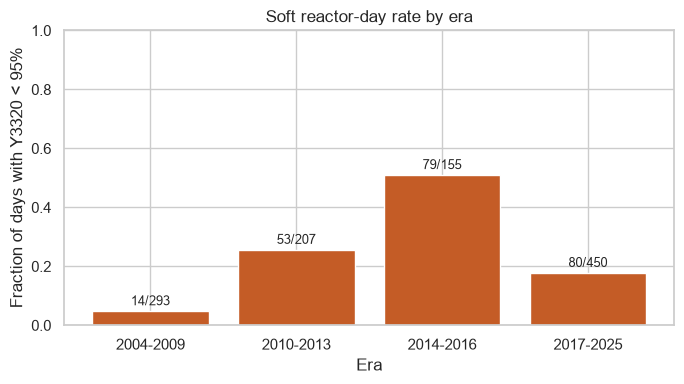

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb05_soft_rate_by_era.png


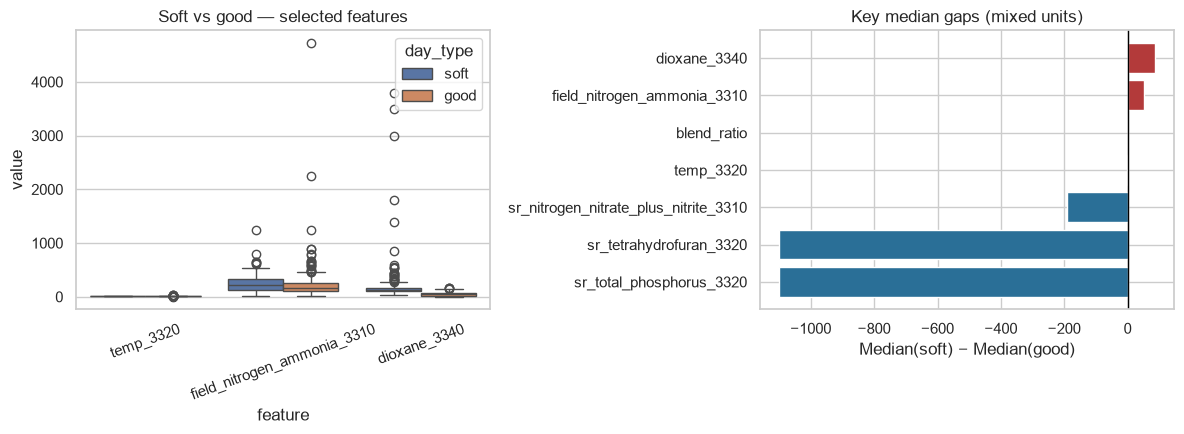

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb05_soft_vs_good_plots.png


In [4]:
# Plot A: soft rate by era
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(era_tbl["era"], era_tbl["soft_rate"], color="#c45c26")
ax.set_ylabel("Fraction of days with Y3320 < 95%")
ax.set_xlabel("Era")
ax.set_title("Soft reactor-day rate by era")
ax.set_ylim(0, 1)
for i, r in era_tbl.iterrows():
    ax.text(i, r["soft_rate"] + 0.02, f"{r['n_soft']:.0f}/{r['n']:.0f}", ha="center", fontsize=9)
fig.tight_layout()
p1 = OUT_DIR / "nb05_soft_rate_by_era.png"
fig.savefig(p1, dpi=150)
plt.show()
print("Saved:", p1)

# Plot B: key median differences (soft - good), sorted
plot_feats = [
    "temp_3320",
    "field_nitrogen_ammonia_3310",
    "sr_nitrogen_nitrate_plus_nitrite_3310",
    "sr_total_phosphorus_3320",
    "sr_tetrahydrofuran_3320",
    "blend_ratio",
    "dioxane_3340",
]
plot_df = key[key["feature"].isin(plot_feats)].copy()
# standardize diff for display: use % diff of medians where scale varies wildly
plot_df["label"] = plot_df["feature"]
plot_df = plot_df.sort_values("diff_median_soft_minus_good")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# left: effluent and temp / ammonia style boxplots for a few readable features
box_feats = ["temp_3320", "field_nitrogen_ammonia_3310", "dioxane_3340"]
box_feats = [f for f in box_feats if f in df.columns]
long = df.melt(
    id_vars=["day_type"],
    value_vars=box_feats,
    var_name="feature",
    value_name="value",
).dropna()
sns.boxplot(data=long, x="feature", y="value", hue="day_type", ax=axes[0])
axes[0].set_title("Soft vs good — selected features")
axes[0].tick_params(axis="x", rotation=20)

# right: horizontal bars of median difference for key features (raw units differ — annotate)
bars = plot_df.copy()
colors = np.where(bars["diff_median_soft_minus_good"] >= 0, "#b33a3a", "#2a6f97")
axes[1].barh(bars["feature"], bars["diff_median_soft_minus_good"], color=colors)
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("Median(soft) − Median(good)")
axes[1].set_title("Key median gaps (mixed units)")
fig.tight_layout()
p2 = OUT_DIR / "nb05_soft_vs_good_plots.png"
fig.savefig(p2, dpi=150)
plt.show()
print("Saved:", p2)

## Step 5 — Optional: can chem/env flag soft days? (time-split classifier)

Backdrop to Notebook 04: continuous % R² failed chronologically. Here we test whether a simple logistic model can **flag soft days** using past→future split (train ≤2016, test ≥2017).

Leakage rules: no `*_3340`, no `dioxane_3320` (Y uses 3320 and 3340).

**Classifier feature rule (Phase 1):** exclude `dioxane_3320`, `blend_ratio`, and `sed_blend_gap` so predictors are not entangled with the 3320→3340 soft-day label. Those blend topology fields remain in the descriptive soft-vs-good comparison only.


Classifier features (15): ['dioxane_3310', 'field_conductivity_3310', 'field_nitrogen_ammonia_3310', 'pH_3310', 'pH_3320', 'temp_3310', 'temp_3320', 'field_total_suspended_solids_3310', 'sr_1_2_dichloroethane_3310', 'sr_1_2_dichloroethane_3320', 'sr_nitrogen_nitrate_plus_nitrite_3310', 'sr_nitrogen_nitrite_3310', 'sr_tetrahydrofuran_3310', 'sr_tetrahydrofuran_3320', 'sr_total_phosphorus_3320']
Train n=655 soft=146 (22.3%)
Test  n=450 soft=80 (17.8%)

Test ROC-AUC = 0.758
Test AUPRC   = 0.401  (chance ≈ 0.178)

Classification report (threshold 0.5):
              precision    recall  f1-score   support

        good       0.93      0.58      0.72       370
        soft       0.29      0.79      0.42        80

    accuracy                           0.62       450
   macro avg       0.61      0.69      0.57       450
weighted avg       0.81      0.62      0.66       450

Top coefficients:
temp_3320                               -0.2463
sr_nitrogen_nitrate_plus_nitrite_3310   -0.2334
sr_t

/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

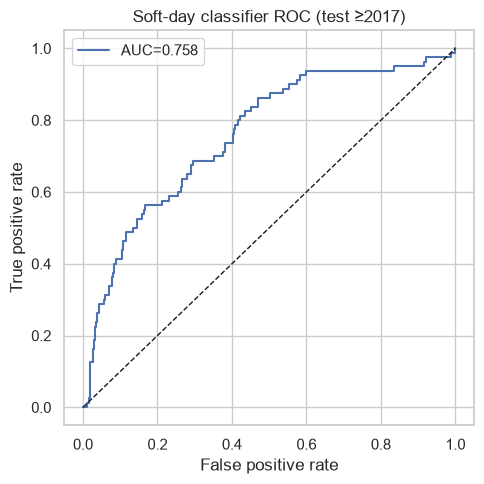

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb05_soft_classifier_roc.png


In [5]:
train_mask = df["date"] <= TRAIN_END
test_mask = df["date"] > TRAIN_END

EXCLUDE_FROM_CLF = {"dioxane_3320", "blend_ratio", "sed_blend_gap"}

clf_feats = []
for c in feat_cols:
    if c in EXCLUDE_FROM_CLF:
        continue
    if df[c].notna().mean() < 0.5:
        continue
    if df.loc[train_mask, c].notna().mean() < 0.5:
        continue
    clf_feats.append(c)

print(f"Classifier features ({len(clf_feats)}): {clf_feats}")

Xtr = df.loc[train_mask, clf_feats]
Xte = df.loc[test_mask, clf_feats]
ytr = df.loc[train_mask, "is_soft"]
yte = df.loc[test_mask, "is_soft"]

print(f"Train n={len(ytr)} soft={ytr.sum()} ({ytr.mean():.1%})")
print(f"Test  n={len(yte)} soft={yte.sum()} ({yte.mean():.1%})")

pipe = Pipeline(
    [
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
        (
            "clf",
            LogisticRegressionCV(
                Cs=10,
                cv=5,
                max_iter=3000,
                class_weight="balanced",
                scoring="roc_auc",
            ),
        ),
    ]
)
pipe.fit(Xtr, ytr)
proba = pipe.predict_proba(Xte)[:, 1]
pred = (proba >= 0.5).astype(int)

auc = roc_auc_score(yte, proba)
auprc = average_precision_score(yte, proba)
print(f"\nTest ROC-AUC = {auc:.3f}")
print(f"Test AUPRC   = {auprc:.3f}  (chance ≈ {yte.mean():.3f})")
print("\nClassification report (threshold 0.5):")
print(classification_report(yte, pred, target_names=["good", "soft"]))

coefs = pd.Series(pipe.named_steps["clf"].coef_[0], index=clf_feats).sort_values(
    key=np.abs, ascending=False
)
coef_path = OUT_DIR / "nb05_soft_classifier_coefficients.csv"
coefs.to_csv(coef_path, header=["coef"])
print("Top coefficients:")
print(coefs.head(10).round(4))

fpr, tpr, _ = roc_curve(yte, proba)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f"AUC={auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Soft-day classifier ROC (test ≥2017)")
ax.legend()
fig.tight_layout()
p3 = OUT_DIR / "nb05_soft_classifier_roc.png"
fig.savefig(p3, dpi=150)
plt.show()
print("Saved:", p3)

metrics = pd.DataFrame(
    [
        {
            "task": "soft95_classifier",
            "train_end": TRAIN_END,
            "n_train": len(ytr),
            "n_test": len(yte),
            "soft_rate_train": ytr.mean(),
            "soft_rate_test": yte.mean(),
            "roc_auc_test": auc,
            "auprc_test": auprc,
            "n_features": len(clf_feats),
        }
    ]
)
metrics.to_csv(OUT_DIR / "nb05_soft_classifier_metrics.csv", index=False)

## Step 5b — SHAP: which features drive soft-day predictions?

Use SHAP on the **fitted 95% soft-day logistic model** (test days ≥2017) to rank chemistry/field features by contribution to the soft-day score.

Interpretation tip: SHAP explains the **model**, not causation. For this linear logistic, rankings should broadly agree with coefficient magnitude, with clearer per-day directionality.


Background dataset has 655 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=655 when initializing the masker.


Top SHAP features (mean |SHAP| on test, soft @ 95%):
sr_total_phosphorus_3320                 0.2336
sr_nitrogen_nitrate_plus_nitrite_3310    0.1378
field_conductivity_3310                  0.1274
dioxane_3310                             0.1262
field_total_suspended_solids_3310        0.1153
temp_3320                                0.1143
sr_tetrahydrofuran_3320                  0.1008
field_nitrogen_ammonia_3310              0.0708
sr_1_2_dichloroethane_3310               0.0663
sr_tetrahydrofuran_3310                  0.0625
sr_nitrogen_nitrite_3310                 0.0600
sr_1_2_dichloroethane_3320               0.0515
dtype: float64
Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb05_shap_mean_abs_soft95.csv


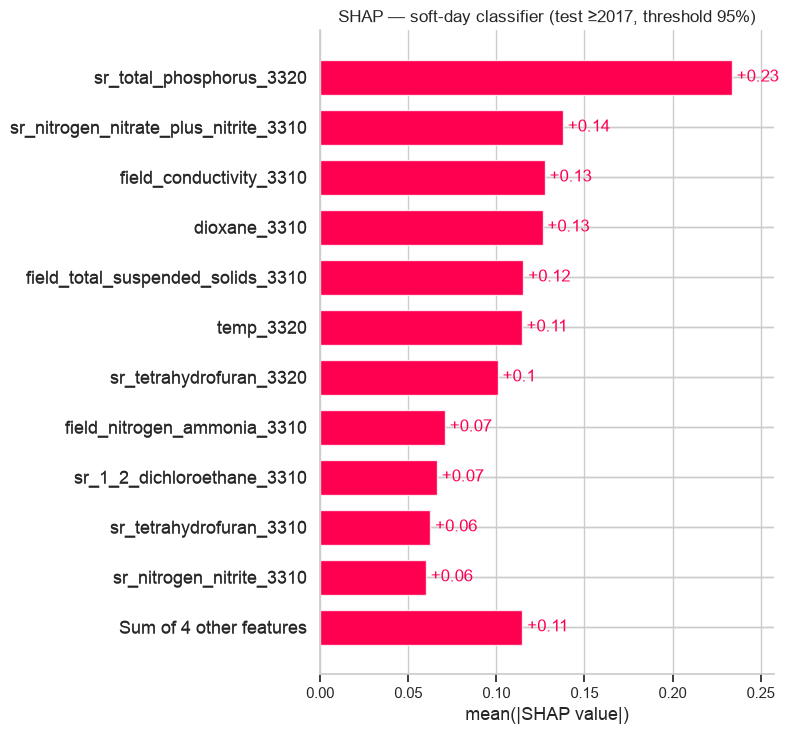

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb05_shap_bar_soft95.png


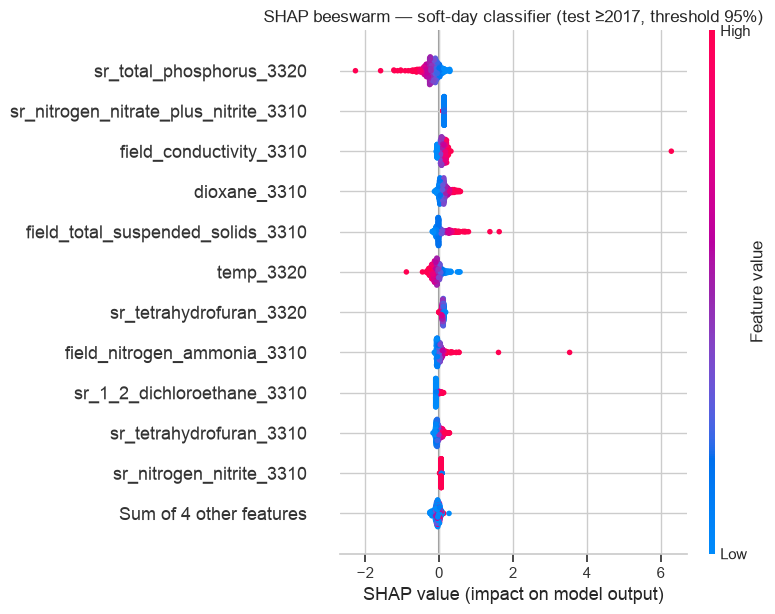

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb05_shap_beeswarm_soft95.png


In [6]:
# Transformed matrices for LinearExplainer (impute + scale, then logistic)
Xtr_t = pipe.named_steps["sc"].transform(pipe.named_steps["imp"].transform(Xtr))
Xte_t = pipe.named_steps["sc"].transform(pipe.named_steps["imp"].transform(Xte))
Xtr_t = pd.DataFrame(Xtr_t, columns=clf_feats)
Xte_t = pd.DataFrame(Xte_t, columns=clf_feats)

explainer = shap.LinearExplainer(pipe.named_steps["clf"], Xtr_t)
shap_exp = explainer(Xte_t)
# Ensure feature names for plots
shap_exp.feature_names = list(clf_feats)

mean_abs = pd.Series(np.abs(shap_exp.values).mean(axis=0), index=clf_feats).sort_values(
    ascending=False
)
shap_rank_path = OUT_DIR / "nb05_shap_mean_abs_soft95.csv"
mean_abs.to_csv(shap_rank_path, header=["mean_abs_shap"])
print("Top SHAP features (mean |SHAP| on test, soft @ 95%):")
print(mean_abs.head(12).round(4))
print("Saved:", shap_rank_path)

# Bar plot
fig = plt.figure(figsize=(7, 5))
shap.plots.bar(shap_exp, max_display=12, show=False)
plt.title("SHAP — soft-day classifier (test ≥2017, threshold 95%)")
plt.tight_layout()
p_bar = OUT_DIR / "nb05_shap_bar_soft95.png"
fig.savefig(p_bar, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", p_bar)

# Beeswarm
fig = plt.figure(figsize=(7, 5))
shap.plots.beeswarm(shap_exp, max_display=12, show=False)
plt.title("SHAP beeswarm — soft-day classifier (test ≥2017, threshold 95%)")
plt.tight_layout()
p_bee = OUT_DIR / "nb05_shap_beeswarm_soft95.png"
fig.savefig(p_bee, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", p_bee)


## Step 5c — Soft-threshold sensitivity

Default soft day = removal < **95%**. Here we repeat labeling + the same temporal logistic classifier at nearby cutoffs (`SOFT_THRESHOLDS`) and compare:

1. class balance (how many soft days)
2. test ROC-AUC / AUPRC
3. top SHAP features (mean |SHAP|) — do the drivers stay stable?

This checks whether the 95% choice is fragile.


/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

threshold=90.0%  soft=  43 (3.9%)  AUC=0.728  AUPRC=0.138  top5=sr_total_phosphorus_3320, sr_1_2_dichloroethane_3310, sr_tetrahydrofuran_3310, dioxane_3310, field_conductivity_3310


/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

Background dataset has 655 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=655 when initializing the masker.


threshold=92.0%  soft=  71 (6.4%)  AUC=0.769  AUPRC=0.200  top5=sr_total_phosphorus_3320, field_conductivity_3310, dioxane_3310, sr_tetrahydrofuran_3310, sr_nitrogen_nitrate_plus_nitrite_3310


...

/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

Background dataset has 655 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=655 when initializing the masker.


threshold=95.0%  soft= 226 (20.5%)  AUC=0.758  AUPRC=0.401  top5=sr_total_phosphorus_3320, sr_nitrogen_nitrate_plus_nitrite_3310, field_conductivity_3310, dioxane_3310, field_total_suspended_solids_3310
threshold=97.0%  soft= 475 (43.0%)  AUC=0.612  AUPRC=0.534  top5=sr_total_phosphorus_3320, sr_tetrahydrofuran_3320, sr_nitrogen_nitrate_plus_nitrite_3310, field_conductivity_3310, dioxane_3310


/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details

threshold=98.0%  soft= 644 (58.3%)  AUC=0.709  AUPRC=0.806  top5=sr_total_phosphorus_3320, sr_1_2_dichloroethane_3310, sr_tetrahydrofuran_3320, sr_nitrogen_nitrate_plus_nitrite_3310, temp_3320

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb05_threshold_sweep_metrics.csv
Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb05_threshold_sweep_top5_shap.csv


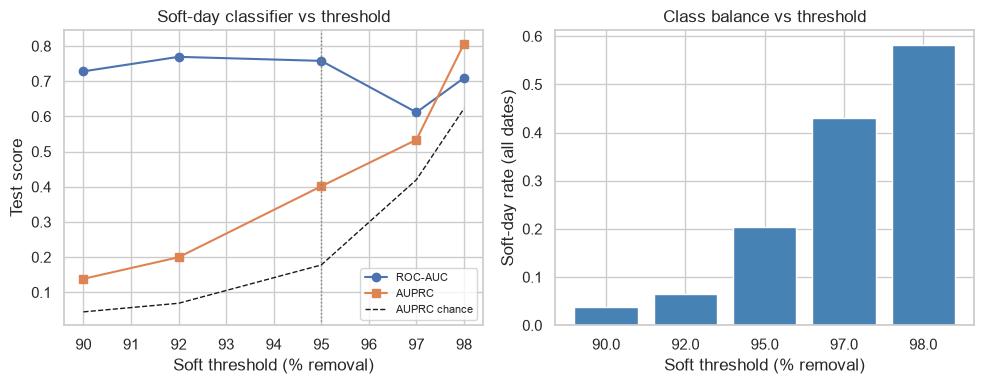

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb05_threshold_sweep.png

Feature stability (times in top-5 SHAP across thresholds):
feature
sr_total_phosphorus_3320                 5
dioxane_3310                             4
field_conductivity_3310                  4
sr_nitrogen_nitrate_plus_nitrite_3310    4
sr_1_2_dichloroethane_3310               2
sr_tetrahydrofuran_3310                  2
sr_tetrahydrofuran_3320                  2
field_total_suspended_solids_3310        1
temp_3320                                1
Name: times_in_top5, dtype: int64


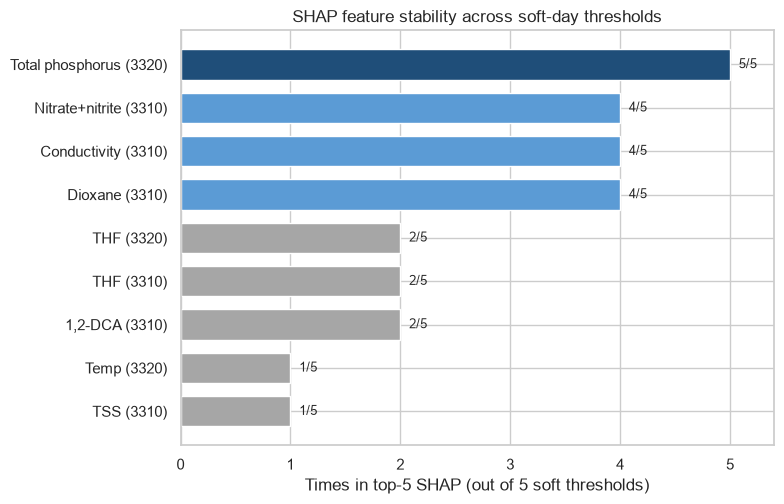

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb05_shap_feature_stability.png


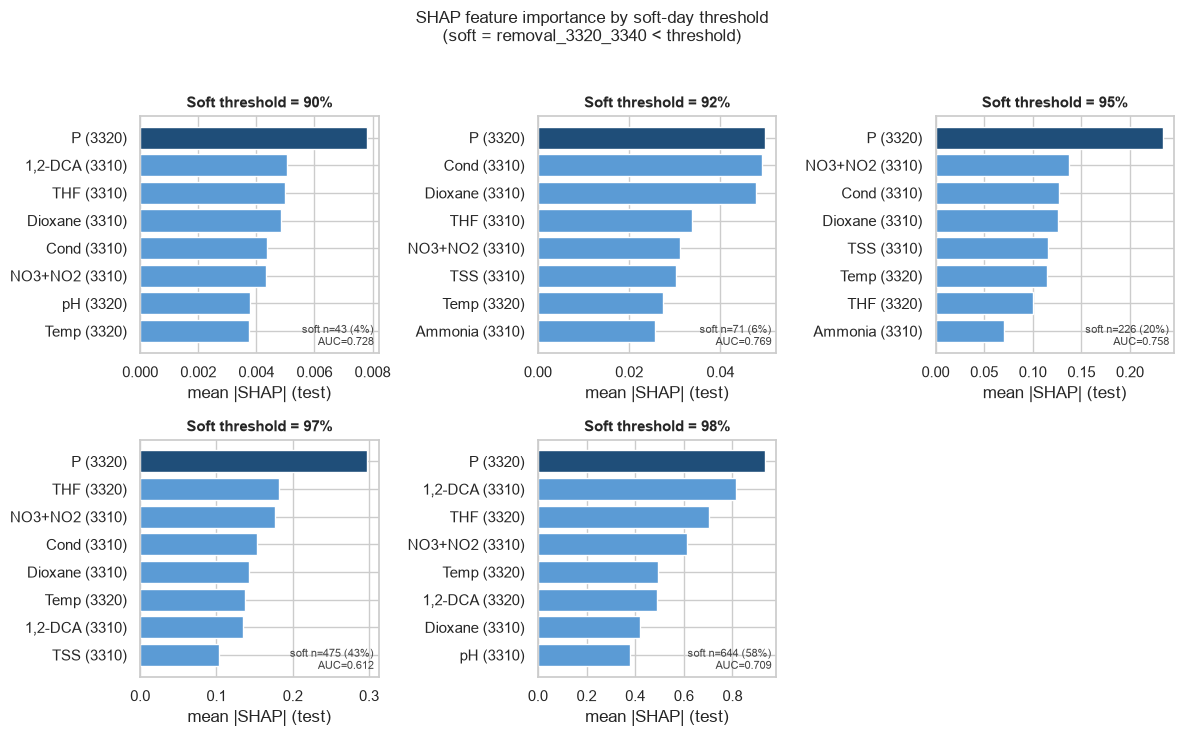

Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb05_shap_bars_by_threshold.png
Saved: /Users/shaivikoul/Documents/DIOPredict LOWRY/data/processed/analysis_results/nb05_shap_mean_abs_by_threshold.csv


In [7]:
EXCLUDE_FROM_CLF = {"dioxane_3320", "blend_ratio", "sed_blend_gap"}


def select_clf_features(frame: pd.DataFrame, train_mask_local: pd.Series) -> list[str]:
    feats = []
    for c in candidate_features(frame):
        if c in EXCLUDE_FROM_CLF:
            continue
        if frame[c].notna().mean() < 0.5:
            continue
        if frame.loc[train_mask_local, c].notna().mean() < 0.5:
            continue
        feats.append(c)
    return feats


def fit_soft_classifier(frame: pd.DataFrame, threshold: float):
    """Label soft days at `threshold`, fit temporal logistic, return metrics + SHAP ranks."""
    local = frame.copy()
    local["is_soft"] = (local["y3320"] < threshold).astype(int)

    tr = local["date"] <= TRAIN_END
    te = local["date"] > TRAIN_END
    feats = select_clf_features(local, tr)
    if not feats:
        raise RuntimeError(f"No features at threshold {threshold}")

    X_tr = local.loc[tr, feats]
    X_te = local.loc[te, feats]
    y_tr = local.loc[tr, "is_soft"]
    y_te = local.loc[te, "is_soft"]

    model = Pipeline(
        [
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            (
                "clf",
                LogisticRegressionCV(
                    Cs=10,
                    cv=5,
                    max_iter=3000,
                    class_weight="balanced",
                    scoring="roc_auc",
                ),
            ),
        ]
    )
    model.fit(X_tr, y_tr)
    proba_te = model.predict_proba(X_te)[:, 1]

    # Guard rare all-one / all-zero labels
    if y_te.nunique() < 2:
        auc_te = np.nan
        auprc_te = np.nan
        top_shap = []
        mean_abs_local = pd.Series(dtype=float)
    else:
        auc_te = roc_auc_score(y_te, proba_te)
        auprc_te = average_precision_score(y_te, proba_te)

        X_tr_t = pd.DataFrame(
            model.named_steps["sc"].transform(model.named_steps["imp"].transform(X_tr)),
            columns=feats,
        )
        X_te_t = pd.DataFrame(
            model.named_steps["sc"].transform(model.named_steps["imp"].transform(X_te)),
            columns=feats,
        )
        exp = shap.LinearExplainer(model.named_steps["clf"], X_tr_t)(X_te_t)
        mean_abs_local = (
            pd.Series(np.abs(exp.values).mean(axis=0), index=feats)
            .sort_values(ascending=False)
        )
        top_shap = list(mean_abs_local.head(5).index)

    return {
        "threshold": threshold,
        "n_total": len(local),
        "n_soft": int(local["is_soft"].sum()),
        "soft_rate": float(local["is_soft"].mean()),
        "n_train": int(tr.sum()),
        "n_test": int(te.sum()),
        "soft_rate_train": float(y_tr.mean()),
        "soft_rate_test": float(y_te.mean()),
        "roc_auc_test": auc_te,
        "auprc_test": auprc_te,
        "chance_auprc_test": float(y_te.mean()),
        "n_features": len(feats),
        "top5_shap": ", ".join(top_shap),
        "mean_abs_shap": mean_abs_local,
        "model": model,
        "feats": feats,
    }


sweep_rows = []
shap_stability = []
shap_by_threshold = {}
for thr in SOFT_THRESHOLDS:
    out = fit_soft_classifier(df, thr)
    shap_by_threshold[thr] = out["mean_abs_shap"]
    sweep_rows.append(
        {k: v for k, v in out.items() if k not in {"model", "feats", "mean_abs_shap"}}
    )
    print(
        f"threshold={thr:4.1f}%  soft={out['n_soft']:4d} ({out['soft_rate']:.1%})  "
        f"AUC={out['roc_auc_test']:.3f}  AUPRC={out['auprc_test']:.3f}  "
        f"top5={out['top5_shap']}"
    )
    for rank, feat in enumerate(out["top5_shap"].split(", ") if out["top5_shap"] else [], start=1):
        shap_stability.append({"threshold": thr, "rank": rank, "feature": feat})

sweep = pd.DataFrame(sweep_rows)
sweep_path = OUT_DIR / "nb05_threshold_sweep_metrics.csv"
sweep.to_csv(sweep_path, index=False)
print("\nSaved:", sweep_path)

stab = pd.DataFrame(shap_stability)
stab_path = OUT_DIR / "nb05_threshold_sweep_top5_shap.csv"
stab.to_csv(stab_path, index=False)
print("Saved:", stab_path)

# Metrics vs threshold
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(sweep["threshold"], sweep["roc_auc_test"], "o-", label="ROC-AUC")
axes[0].plot(sweep["threshold"], sweep["auprc_test"], "s-", label="AUPRC")
axes[0].plot(sweep["threshold"], sweep["chance_auprc_test"], "k--", lw=1, label="AUPRC chance")
axes[0].axvline(SOFT_THRESHOLD, color="gray", ls=":", lw=1)
axes[0].set_xlabel("Soft threshold (% removal)")
axes[0].set_ylabel("Test score")
axes[0].set_title("Soft-day classifier vs threshold")
axes[0].legend(fontsize=8)

axes[1].bar(sweep["threshold"].astype(str), sweep["soft_rate"], color="steelblue")
axes[1].set_xlabel("Soft threshold (% removal)")
axes[1].set_ylabel("Soft-day rate (all dates)")
axes[1].set_title("Class balance vs threshold")
fig.tight_layout()
p_sweep = OUT_DIR / "nb05_threshold_sweep.png"
fig.savefig(p_sweep, dpi=150)
plt.show()
print("Saved:", p_sweep)

# Feature stability: how often each feature appears in top-5 across thresholds
freq = (
    stab.groupby("feature").size().sort_values(ascending=False).rename("times_in_top5")
)
print("\nFeature stability (times in top-5 SHAP across thresholds):")
print(freq.head(12))

# Visual: horizontal bar of stability counts
freq_plot = freq.sort_values(ascending=True)
label_map = {
    "sr_total_phosphorus_3320": "Total phosphorus (3320)",
    "dioxane_3310": "Dioxane (3310)",
    "field_conductivity_3310": "Conductivity (3310)",
    "sed_blend_gap": "Sed–blend dioxane gap",
    "sr_1_2_dichloroethane_3310": "1,2-DCA (3310)",
    "sr_nitrogen_nitrate_plus_nitrite_3310": "Nitrate+nitrite (3310)",
    "sr_tetrahydrofuran_3310": "THF (3310)",
    "field_total_suspended_solids_3310": "TSS (3310)",
    "sr_tetrahydrofuran_3320": "THF (3320)",
    "temp_3320": "Temp (3320)",
}
n_cut = len(SOFT_THRESHOLDS)
labels = [label_map.get(f, f) for f in freq_plot.index]
colors = [
    "#1f4e79" if v == n_cut else "#5b9bd5" if v >= 3 else "#a6a6a6" for v in freq_plot.values
]
fig, ax = plt.subplots(figsize=(8, 5.2))
bars = ax.barh(labels, freq_plot.values, color=colors, edgecolor="white", height=0.7)
ax.set_xlabel(f"Times in top-5 SHAP (out of {n_cut} soft thresholds)")
ax.set_title("SHAP feature stability across soft-day thresholds")
ax.set_xlim(0, n_cut + 0.4)
ax.set_xticks(range(0, n_cut + 1))
for bar, v in zip(bars, freq_plot.values):
    ax.text(
        v + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{int(v)}/{n_cut}",
        va="center",
        ha="left",
        fontsize=9,
    )
fig.tight_layout()
p_stab = OUT_DIR / "nb05_shap_feature_stability.png"
fig.savefig(p_stab, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", p_stab)

# Panel: SHAP bar importance for each soft threshold (clearly labeled)
label_map_panel = {
    "sr_total_phosphorus_3320": "P (3320)",
    "sr_nitrogen_nitrate_plus_nitrite_3310": "NO3+NO2 (3310)",
    "field_total_suspended_solids_3310": "TSS (3310)",
    "field_conductivity_3310": "Cond (3310)",
    "temp_3320": "Temp (3320)",
    "sed_blend_gap": "Sed-blend gap",
    "sr_tetrahydrofuran_3320": "THF (3320)",
    "sr_tetrahydrofuran_3310": "THF (3310)",
    "dioxane_3310": "Dioxane (3310)",
    "sr_1_2_dichloroethane_3310": "1,2-DCA (3310)",
    "sr_1_2_dichloroethane_3320": "1,2-DCA (3320)",
    "blend_ratio": "Blend ratio",
    "field_nitrogen_ammonia_3310": "Ammonia (3310)",
    "sr_nitrogen_nitrite_3310": "Nitrite (3310)",
    "pH_3320": "pH (3320)",
    "pH_3310": "pH (3310)",
    "temp_3310": "Temp (3310)",
}

n_thr = len(SOFT_THRESHOLDS)
n_cols = 3
n_rows = int(np.ceil(n_thr / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.6 * n_rows), sharex=False)
axes = np.atleast_1d(axes).ravel()

for ax, thr in zip(axes, SOFT_THRESHOLDS):
    s = shap_by_threshold[thr].sort_values(ascending=True).tail(8)
    pretty = [label_map_panel.get(i, i) for i in s.index]
    colors = ["#1f4e79" if i == "sr_total_phosphorus_3320" else "#5b9bd5" for i in s.index]
    ax.barh(pretty, s.values, color=colors, edgecolor="white")
    ax.set_title(f"Soft threshold = {thr:.0f}%", fontsize=11, fontweight="bold")
    soft_n = int(sweep.loc[sweep["threshold"] == thr, "n_soft"].iloc[0])
    soft_rate = float(sweep.loc[sweep["threshold"] == thr, "soft_rate"].iloc[0])
    auc_v = float(sweep.loc[sweep["threshold"] == thr, "roc_auc_test"].iloc[0])
    ax.set_xlabel("mean |SHAP| (test)")
    ax.text(
        0.98,
        0.02,
        f"soft n={soft_n} ({soft_rate:.0%})\nAUC={auc_v:.3f}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        color="#444444",
    )

for ax in axes[n_thr:]:
    ax.axis("off")

fig.suptitle(
    "SHAP feature importance by soft-day threshold\n(soft = removal_3320_3340 < threshold)",
    fontsize=12,
    y=1.02,
)
fig.tight_layout()
p_panel = OUT_DIR / "nb05_shap_bars_by_threshold.png"
fig.savefig(p_panel, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", p_panel)

# Also save long-form mean |SHAP| table for all thresholds
shap_long_rows = []
for thr, s in shap_by_threshold.items():
    for feat, val in s.items():
        shap_long_rows.append({"threshold": thr, "feature": feat, "mean_abs_shap": val})
shap_long = pd.DataFrame(shap_long_rows).sort_values(
    ["threshold", "mean_abs_shap"], ascending=[True, False]
)
shap_long_path = OUT_DIR / "nb05_shap_mean_abs_by_threshold.csv"
shap_long.to_csv(shap_long_path, index=False)
print("Saved:", shap_long_path)

plt.close('all')  # keep later table outputs from colliding with leftover figures


## Step 6 — Key findings (tables)

Summary tables for the soft vs good analysis, SHAP drivers, and threshold sensitivity.  
Also written to `data/processed/analysis_results/nb05_KEY_FINDINGS.md` and `nb05_VERDICT.txt`.


### In plain English — good days vs soft days

Think of each day as either:

- **Good day** — reactors are removing dioxane well (about 95%+ from blend → effluent)
- **Soft day** — reactors are underperforming (below that line)

#### Simple picture

| | Good days | Soft days |
|--|--|--|
| Reactor performance | Strong dioxane removal | Weaker dioxane removal |
| Phosphorus | Higher | Lower |
| Nitrate/nitrite | Higher | Lower |
| Ammonia | Lower | Higher |
| Incoming dioxane | Lower | Higher |
| Temperature | A bit warmer | A bit cooler |

**Strongest stable signal:** lower phosphorus on soft days (top SHAP feature at every threshold we tried).

**Why this matters:** this chemistry fingerprint suggests testable microbial hypotheses (e.g. nutrient-related communities) when more 16S data arrive.

**Limits:** these are associations from chemistry/field data — not proof that any one feature *causes* soft days. The classifier also excludes blend topology features (`blend_ratio`, `sed_blend_gap`) so the story stays on chemistry drivers not entangled with the label.


In [8]:
from IPython.display import Markdown, display

FEATURE_LABELS = {
    "sr_total_phosphorus_3320": "Phosphorus (3320)",
    "sr_nitrogen_nitrate_plus_nitrite_3310": "Nitrate/nitrite (3310)",
    "field_nitrogen_ammonia_3310": "Ammonia (3310)",
    "dioxane_3310": "Incoming dioxane (3310)",
    "dioxane_3320": "Dioxane (3320)",
    "dioxane_3340": "Dioxane (3340)",
    "field_conductivity_3310": "Conductivity (3310)",
    "field_total_suspended_solids_3310": "TSS (3310)",
    "temp_3320": "Temperature (3320)",
    "temp_3310": "Temperature (3310)",
    "sr_tetrahydrofuran_3310": "THF (3310)",
    "sr_tetrahydrofuran_3320": "THF (3320)",
    "sr_1_2_dichloroethane_3310": "1,2-DCA (3310)",
    "sr_1_2_dichloroethane_3320": "1,2-DCA (3320)",
    "sr_nitrogen_nitrite_3310": "Nitrite (3310)",
    "pH_3310": "pH (3310)",
    "pH_3320": "pH (3320)",
    "blend_ratio": "Blend ratio",
    "sed_blend_gap": "Sed–blend gap",
    "removal_3310_3340": "Removal 3310→3340",
}

def pretty_feature(name: str) -> str:
    return FEATURE_LABELS.get(name, name)


# --- Setup table ---
setup_tbl = pd.DataFrame(
    [
        ["Soft-day definition (default)", f"{Y_COL} < {SOFT_THRESHOLD}%"],
        ["Soft / good / total", f"{(df['day_type']=='soft').sum()} / {(df['day_type']=='good').sum()} / {len(df)}"],
        ["Train / test", f"train ≤ {TRAIN_END}; test after"],
        ["Classifier features", f"{len(clf_feats)} chemistry/field features"],
        ["Excluded from classifier", "dioxane_3320, blend_ratio, sed_blend_gap"],
        ["Test ROC-AUC @ 95%", f"{auc:.3f}"],
        ["Test AUPRC @ 95%", f"{auprc:.3f} (chance ≈ {yte.mean():.3f})"],
    ],
    columns=["Item", "Value"],
)

# --- Soft vs good medians ---
median_tbl = key.copy()
median_tbl["direction"] = np.where(
    median_tbl["diff_median_soft_minus_good"] > 0, "Higher on soft", "Lower on soft"
)
median_tbl = median_tbl[
    ["feature", "median_soft", "median_good", "direction", "mannwhitney_p"]
].rename(
    columns={
        "feature": "Feature",
        "median_soft": "Soft median",
        "median_good": "Good median",
        "direction": "Direction",
        "mannwhitney_p": "p-value",
    }
)

# --- SHAP @ 95% ---
shap_tbl = (
    mean_abs.head(8)
    .rename("mean_|SHAP|")
    .reset_index()
    .rename(columns={"index": "Feature"})
)
shap_tbl.insert(0, "Rank", range(1, len(shap_tbl) + 1))

# --- Threshold sweep ---
sweep_tbl = sweep[["threshold", "soft_rate", "roc_auc_test", "auprc_test"]].copy()
sweep_tbl["soft_rate"] = (sweep_tbl["soft_rate"] * 100).round(1).astype(str) + "%"
sweep_tbl = sweep_tbl.rename(
    columns={
        "threshold": "Soft if removal <",
        "soft_rate": "Soft rate",
        "roc_auc_test": "Test ROC-AUC",
        "auprc_test": "Test AUPRC",
    }
)

# --- Stability ---
stab_tbl = (
    freq.head(10)
    .rename("times_in_top5")
    .reset_index()
    .rename(columns={"feature": "Feature", "times_in_top5": "Times in top-5"})
)
stab_tbl["Times in top-5"] = (
    stab_tbl["Times in top-5"].astype(str) + f" / {len(SOFT_THRESHOLDS)}"
)

# --- Simple picture ---
simple_tbl = pd.DataFrame(
    [
        ["Reactor performance", "Strong dioxane removal", "Weaker dioxane removal"],
        ["Phosphorus", "Higher", "Lower"],
        ["Nitrate/nitrite", "Higher", "Lower"],
        ["Ammonia", "Lower", "Higher"],
        ["Incoming dioxane", "Lower", "Higher"],
        ["Temperature", "A bit warmer", "A bit cooler"],
    ],
    columns=["", "Good days", "Soft days"],
)
display(Markdown("### Simple picture — good days vs soft days"))
display(simple_tbl)

display(Markdown("### Setup & classifier (default 95%)"))
display(setup_tbl)
median_tbl["Feature"] = median_tbl["Feature"].map(pretty_feature)
display(Markdown("### Soft vs good — key median differences (@ 95%)"))
display(median_tbl.round({"Soft median": 4, "Good median": 4}))
shap_tbl["Feature"] = shap_tbl["Feature"].map(pretty_feature)
display(Markdown("### SHAP top drivers (@ 95%, test)"))
display(shap_tbl.round({"mean_|SHAP|": 4}))
display(Markdown("### Soft-threshold sensitivity"))
display(sweep_tbl.round({"Test ROC-AUC": 3, "Test AUPRC": 3}))
stab_tbl["Feature"] = stab_tbl["Feature"].map(pretty_feature)
display(Markdown("### SHAP feature stability across thresholds"))
display(stab_tbl)
display(
    Markdown(
        "**Bottom line:** SHAP identifies stable soft-day chemistry drivers — especially "
        "**phosphorus (3320)** and **nitrate+nitrite (3310)** — giving concrete microbial "
        "hypotheses to test when more 16S data arrive.\n\n"
        "*Limits: associations only; not causal. Classifier excludes label-entangled blend features.*"
    )
)

# --- Write markdown + compact text files (no big print dump — avoids notebook overlap) ---
def df_to_md(frame: pd.DataFrame) -> str:
    return frame.to_markdown(index=False)


md_lines = [
    "# NB05 Key Findings — Soft vs Good Reactor Days",
    "",
    "## Simple picture — good days vs soft days",
    "",
    df_to_md(simple_tbl),
    "",
    "## Setup & classifier (default 95%)",
    "",
    df_to_md(setup_tbl),
    "",
    "## Soft vs good — key median differences (@ 95%)",
    "",
    df_to_md(median_tbl.round({"Soft median": 4, "Good median": 4})),
    "",
    "## SHAP top drivers (@ 95%, test)",
    "",
    df_to_md(shap_tbl.round({"mean_|SHAP|": 4})),
    "",
    "## Soft-threshold sensitivity",
    "",
    df_to_md(sweep_tbl.round({"Test ROC-AUC": 3, "Test AUPRC": 3})),
    "",
    "## SHAP feature stability across thresholds",
    "",
    df_to_md(stab_tbl),
    "",
    "## Bottom line",
    "",
    "SHAP identifies stable soft-day chemistry drivers — especially **phosphorus (3320)** "
    "and **nitrate+nitrite (3310)** — giving concrete microbial hypotheses to test when more 16S data arrive.",
    "",
    "Limits: associations only; not causal. Classifier excludes dioxane_3320, blend_ratio, sed_blend_gap.",
]
key_path = OUT_DIR / "nb05_KEY_FINDINGS.md"
key_path.write_text("\n".join(md_lines))

lines = [
    "NB05 VERDICT — Soft vs good reactor days",
    "=" * 60,
    f"Soft = {Y_COL} < {SOFT_THRESHOLD}%  (default)",
    f"n_soft={(df['day_type']=='soft').sum()}  n_good={(df['day_type']=='good').sum()}  total={len(df)}",
    f"Soft-day classifier: ROC-AUC={auc:.3f}, AUPRC={auprc:.3f} (chance≈{yte.mean():.3f})",
    "SHAP top: " + ", ".join(mean_abs.head(5).index),
    "Stable top-5: "
    + ", ".join(f"{feat} ({n}/{len(SOFT_THRESHOLDS)})" for feat, n in freq.head(4).items()),
    "Classifier excludes dioxane_3320, blend_ratio, sed_blend_gap.",
    "See nb05_KEY_FINDINGS.md for full tables.",
]
verdict_path = OUT_DIR / "nb05_VERDICT.txt"
verdict_path.write_text("\n".join(lines))

display(Markdown(
    f"<br/>Saved: `{key_path.name}` and `{verdict_path.name}` under `data/processed/analysis_results/`."
))


### Simple picture — good days vs soft days

,,Good days,Soft days
0,Reactor performance,Strong dioxane removal,Weaker dioxane removal
1,Phosphorus,Higher,Lower
2,Nitrate/nitrite,Higher,Lower
3,Ammonia,Lower,Higher
4,Incoming dioxane,Lower,Higher
5,Temperature,A bit warmer,A bit cooler


### Setup & classifier (default 95%)

,Item,Value
0,Soft-day definition (default),removal_3320_3340 < 95.0%
1,Soft / good / total,226 / 879 / 1105
2,Train / test,train ≤ 2016-12-31; test after
3,Classifier features,15 chemistry/field features
4,Excluded from classifier,"dioxane_3320, blend_ratio, sed_blend_gap"
5,Test ROC-AUC @ 95%,0.758
6,Test AUPRC @ 95%,0.401 (chance ≈ 0.178)


### Soft vs good — key median differences (@ 95%)

...

,Soft if removal <,Soft rate,Test ROC-AUC,Test AUPRC
0,90.0,3.9%,0.728,0.138
1,92.0,6.4%,0.769,0.200
2,95.0,20.5%,0.758,0.401
3,97.0,43.0%,0.612,0.534
4,98.0,58.3%,0.709,0.806


### SHAP feature stability across thresholds

,Feature,Times in top-5
0,Phosphorus (3320),5 / 5
1,Incoming dioxane (3310),4 / 5
2,Conductivity (3310),4 / 5
3,Nitrate/nitrite (3310),4 / 5
4,"1,2-DCA (3310)",2 / 5
5,THF (3310),2 / 5
6,THF (3320),2 / 5
7,TSS (3310),1 / 5
8,Temperature (3320),1 / 5


**Bottom line:** SHAP identifies stable soft-day chemistry drivers — especially **phosphorus (3320)** and **nitrate+nitrite (3310)** — giving concrete microbial hypotheses to test when more 16S data arrive.

*Limits: associations only; not causal. Classifier excludes label-entangled blend features.*

<br/>Saved: `nb05_KEY_FINDINGS.md` and `nb05_VERDICT.txt` under `data/processed/analysis_results/`.